<a href="https://colab.research.google.com/github/4shk6/Household-Energy-Consumption-Using--Machine-Learning-Models-/blob/main/ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


from statsmodels.tsa.seasonal import seasonal_decompose


import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load dataset
df = pd.read_csv(
    "/content/household_power_consumption.txt",
    sep=";",
    low_memory=False,
    na_values=["?"]
)

df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S"
)

df.set_index("Datetime", inplace=True)
df.drop(["Date", "Time"], axis=1, inplace=True)


In [4]:
df = df.apply(pd.to_numeric, errors="coerce")


In [5]:
df.isnull().sum()


,0
Global_active_power,6
Global_reactive_power,6
Voltage,6
Global_intensity,6
Sub_metering_1,6
Sub_metering_2,7
Sub_metering_3,7


In [6]:

df.fillna(method="ffill", inplace=True)
df.fillna(method="bfill", inplace=True)


In [7]:
df_hourly = df.resample("H").mean()
df_hourly.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [8]:
df_hourly["hour"] = df_hourly.index.hour
df_hourly["day"] = df_hourly.index.day
df_hourly["month"] = df_hourly.index.month
df_hourly["dayofweek"] = df_hourly.index.dayofweek


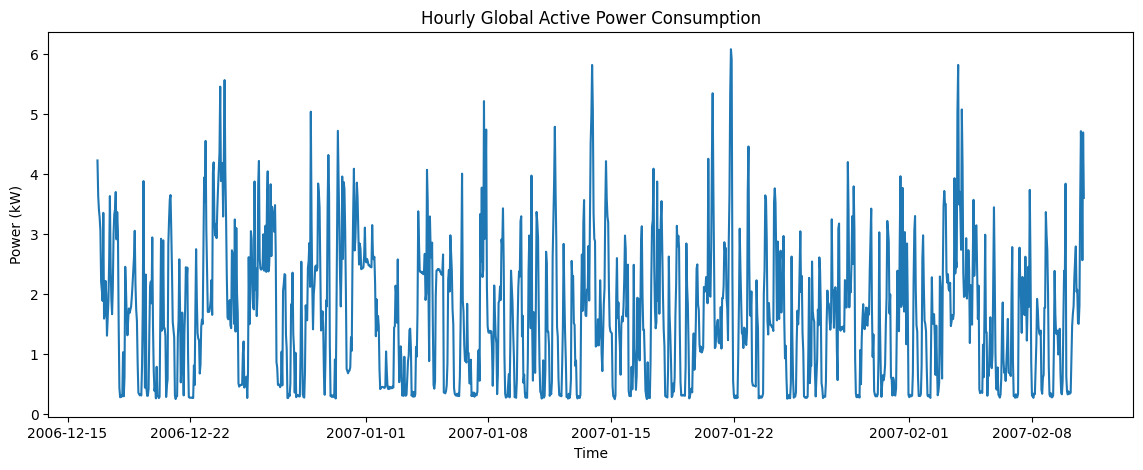

In [9]:
plt.figure(figsize=(14,5))
plt.plot(df_hourly["Global_active_power"])
plt.title("Hourly Global Active Power Consumption")
plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.show()


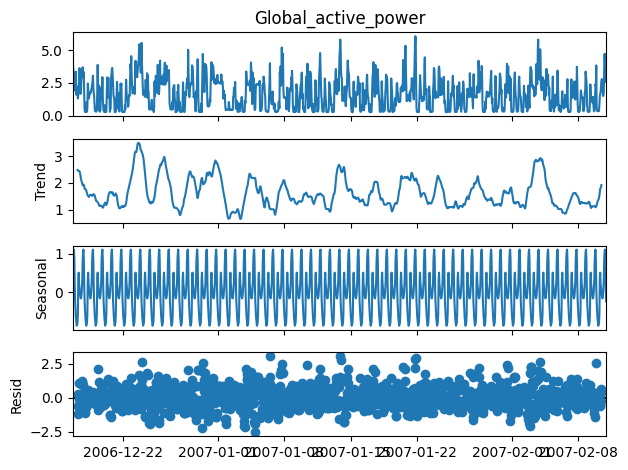

In [10]:
decomposition = seasonal_decompose(
    df_hourly["Global_active_power"].dropna(),
    model="additive",
    period=24
)

decomposition.plot()
plt.show()


In [11]:
X = df_hourly.drop("Global_active_power", axis=1)
y = df_hourly["Global_active_power"]

split_index = int(len(df_hourly) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


In [14]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [15]:
svr = SVR(kernel="rbf", C=100, gamma=0.1)
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)


In [16]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} Performance:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")
    print("-" * 40)


In [17]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_svr, "Support Vector Regression")


Linear Regression Performance:
MAE: 0.0151
RMSE: 0.0206
R2 Score: 0.9997
----------------------------------------
Random Forest Performance:
MAE: 0.0182
RMSE: 0.0260
R2 Score: 0.9995
----------------------------------------
Support Vector Regression Performance:
MAE: 0.1085
RMSE: 0.2264
R2 Score: 0.9593
----------------------------------------


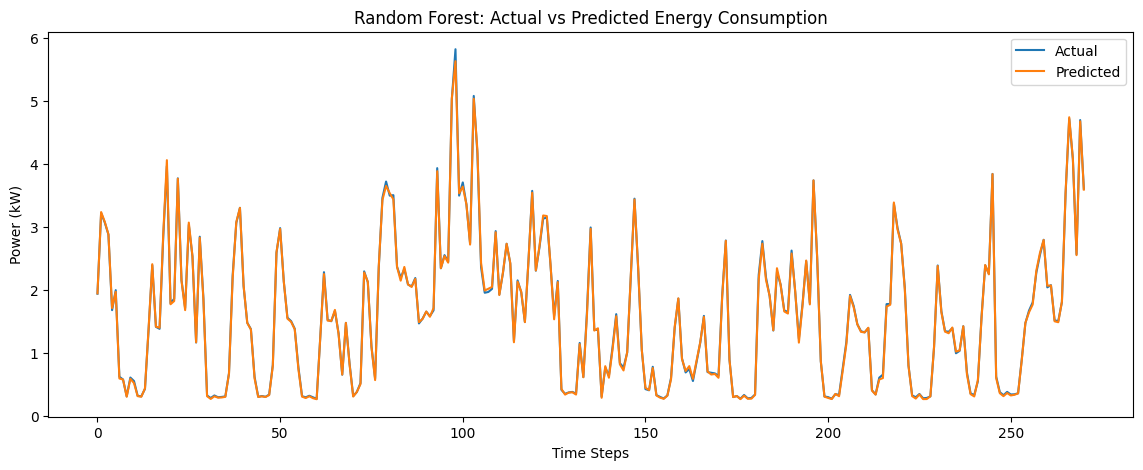

In [18]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred_rf[:500], label="Predicted")
plt.title("Random Forest: Actual vs Predicted Energy Consumption")
plt.xlabel("Time Steps")
plt.ylabel("Power (kW)")
plt.legend()
plt.show()


In [19]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "SVR"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_svr)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_svr))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_svr)
    ]
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,0.015087,0.020641,0.999662
1,Random Forest,0.018206,0.025955,0.999465
2,SVR,0.108550,0.226379,0.959332
